In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW

warnings.filterwarnings('ignore')

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cpu


In [3]:
DATA_PATH       = r'C:\Users\sandy\Downloads\Neural-Project-main\Neural-Project-main\final_neural_network_data.csv'
TREATMENTS_PATH = r'C:\Users\sandy\Downloads\Neural-Project-main\Neural-Project-main\skin_disease_dataset2222\treatments.csv'
MODEL_SAVE_DIR  = 'best_bert_model'
RESULTS_DIR     = 'results'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

MAX_LEN    = 256
BATCH_SIZE = 8
EPOCHS     = 10
LR         = 2e-5
TEST_SIZE  = 0.15
VAL_SIZE   = 0.15
BERT_NAME  = 'bert-base-uncased'

In [4]:
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Disease', 'Description'])
df['Description'] = df['Description'].str.strip()
df['Disease']     = df['Disease'].str.strip().str.title()

print('Shape:', df.shape)
print(df['Disease'].value_counts())

Shape: (103, 3)
Disease
Eczema                13
Warts                 13
Impetigo              13
Acne                  13
Contact Dermatitis    13
Skin Cancer           13
Psoriasis             13
Vitiligo              12
Name: count, dtype: int64


In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Disease'])
num_classes  = len(le.classes_)
print('Classes:', le.classes_)
print('Num classes:', num_classes)

Classes: ['Acne' 'Contact Dermatitis' 'Eczema' 'Impetigo' 'Psoriasis' 'Skin Cancer'
 'Vitiligo' 'Warts']
Num classes: 8


In [6]:
X = df['Description'].tolist()
y = df['label'].tolist()

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=SEED,
    stratify=y_trainval
)

print('Train:', len(X_train), '| Val:', len(X_val), '| Test:', len(X_test))

Train: 71 | Val: 16 | Test: 16


In [ ]:
tokenizer = BertTokenizer.from_pretrained(BERT_NAME)

In [8]:
class SkinDiseaseDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
train_ds = SkinDiseaseDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = SkinDiseaseDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = SkinDiseaseDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

In [10]:
model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=num_classes)
model = model.to(DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

In [12]:
def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss   = outputs.loss
            logits = outputs.logits

        if training:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = (np.array(all_preds) == np.array(all_labels)).mean()
    return avg_loss, acc, np.array(all_preds), np.array(all_labels)

In [13]:
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_epoch   = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, training=True)
    vl_loss, vl_acc, _, _ = run_epoch(val_loader,   training=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    saved = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_epoch   = epoch
        model.save_pretrained(MODEL_SAVE_DIR)
        tokenizer.save_pretrained(MODEL_SAVE_DIR)
        saved = ' -- saved'

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'Train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
        f'Val loss={vl_loss:.4f} acc={vl_acc:.4f}{saved}'
    )

print(f'Best epoch: {best_epoch}  val_acc={best_val_acc:.4f}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 01/10 | Train loss=2.1313 acc=0.0704 | Val loss=2.0743 acc=0.0625 -- saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 02/10 | Train loss=1.9830 acc=0.2817 | Val loss=2.0125 acc=0.1875 -- saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 06/10 | Train loss=1.5325 acc=0.6620 | Val loss=1.6713 acc=0.6250 -- saved
Epoch 07/10 | Train loss=1.4447 acc=0.7746 | Val loss=1.5103 acc=0.6250


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 08/10 | Train loss=1.3827 acc=0.8310 | Val loss=1.5308 acc=0.8125 -- saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 09/10 | Train loss=1.2946 acc=0.9155 | Val loss=1.4638 acc=0.8750 -- saved
Epoch 10/10 | Train loss=1.2888 acc=0.8873 | Val loss=1.4328 acc=0.8125
Best epoch: 9  val_acc=0.8750


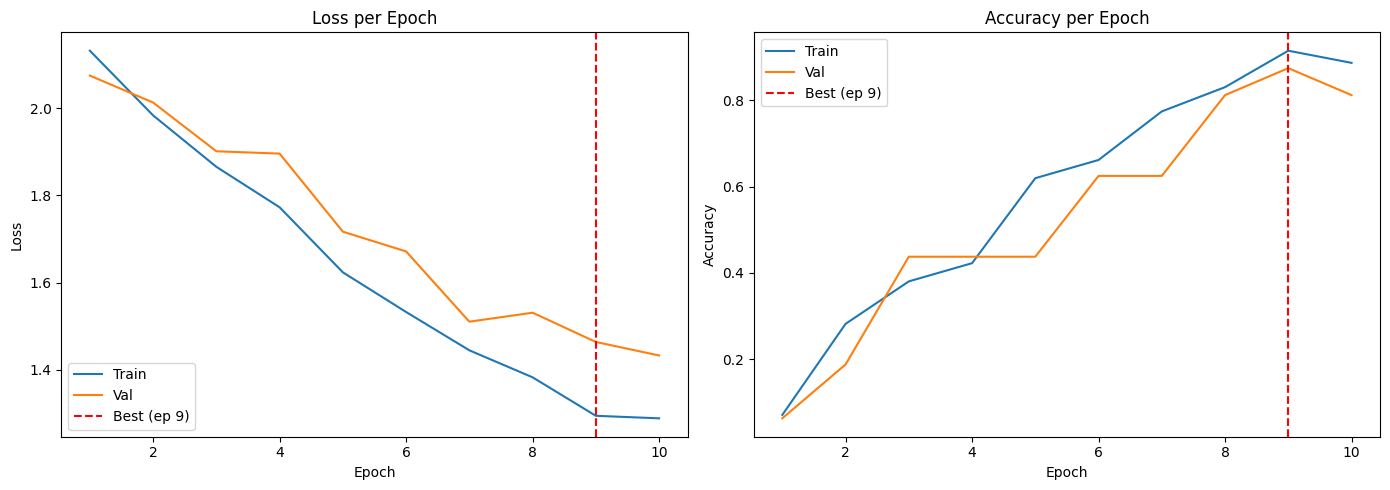

In [14]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best (ep {best_epoch})')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Best (ep {best_epoch})')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [15]:
model = BertForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
model = model.to(DEVICE)

_, test_acc, test_preds, test_labels = run_epoch(test_loader, training=False)

print('Test Accuracy:', round(test_acc, 4))
print()
print(classification_report(test_labels, test_preds, target_names=le.classes_))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test Accuracy: 0.6875

                    precision    recall  f1-score   support

              Acne       1.00      0.50      0.67         2
Contact Dermatitis       1.00      1.00      1.00         2
            Eczema       0.50      1.00      0.67         2
          Impetigo       1.00      1.00      1.00         2
         Psoriasis       0.00      0.00      0.00         2
       Skin Cancer       1.00      1.00      1.00         2
          Vitiligo       0.00      0.00      0.00         2
             Warts       1.00      1.00      1.00         2

          accuracy                           0.69        16
         macro avg       0.69      0.69      0.67        16
      weighted avg       0.69      0.69      0.67        16



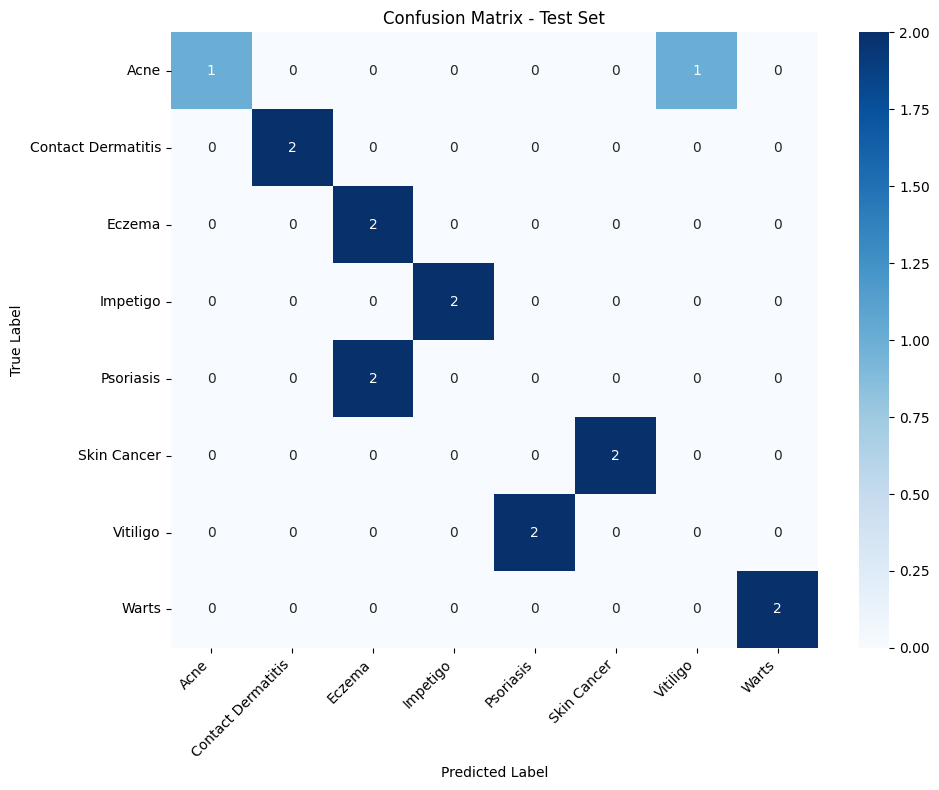

In [16]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [17]:
treatments_df = pd.read_csv(TREATMENTS_PATH)[['Disease', 'Treatment', 'Avoid']]
treatments_df['Disease'] = treatments_df['Disease'].str.strip().str.title()
treatment_map = treatments_df.set_index('Disease').to_dict(orient='index')

In [18]:
def predict_disease(description, top_k=3):
    model.eval()
    enc = tokenizer(
        description,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

    probs   = torch.softmax(logits, dim=1).cpu().numpy()[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    top_preds = [
        {'disease': le.classes_[i], 'confidence': round(probs[i] * 100, 2)}
        for i in top_idx
    ]

    best_disease   = top_preds[0]['disease']
    treatment_info = treatment_map.get(
        best_disease,
        {'Treatment': 'Not available', 'Avoid': 'Not available'}
    )

    return {
        'top_predictions':      top_preds,
        'recommended_disease':  best_disease,
        'confidence':           top_preds[0]['confidence'],
        'treatment':            treatment_info.get('Treatment', 'N/A'),
        'avoid':                treatment_info.get('Avoid',     'N/A'),
    }

In [ ]:
while True:
    user_input = input('Enter skin description (or quit): ').strip()
    if user_input.lower() in ('quit', 'exit', 'q'):
        break
    if not user_input:
        print('Please enter a description.')
        continue

    result = predict_disease(user_input)

    print('\nPredicted Disease :', result['recommended_disease'])
    print('Confidence        :', result['confidence'], '%')
    print('Treatment         :', result['treatment'])
    print('Avoid             :', result['avoid'])
    print('\nAll Predictions:')
    for i, p in enumerate(result['top_predictions'], 1):
        print(f'  {i}. {p["disease"]:<25} {p["confidence"]:>6.2f}%')
    print()


Predicted Disease : Impetigo
Confidence        : 22.85 %
Treatment         : Topical or oral antibiotics (e.g., mupirocin)
Avoid             : Avoid close contact and touching lesions

All Predictions:
  1. Impetigo                   22.85%
  2. Warts                      18.98%
  3. Contact Dermatitis         16.45%

Please enter a description.
